In [1]:
# library
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import seaborn as sns

In [2]:
# data loading
df_person = pd.read_csv('dataset_postur_sam.csv')
df_v3 = pd.read_csv('dataset_postur_v3.csv')

df_main = pd.concat([df_person, df_v3])
df_main.head()

,x1,y1,z1,v1,x2,y2,z2,v2,x3,y3,...,v31,x32,y32,z32,v32,x33,y33,z33,v33,class
0,0.456491,0.500501,-1.248432,0.999926,0.481098,0.434780,-1.174256,0.999874,0.499943,0.433269,...,0.005120,0.623717,2.907377,0.327579,0.004946,0.431786,2.927546,-0.045774,0.004597,Normal
1,0.459317,0.514191,-1.261542,0.999931,0.484977,0.448037,-1.192497,0.999879,0.503728,0.446432,...,0.003886,0.605110,2.944485,0.321116,0.003215,0.408854,2.970578,-0.127117,0.002988,Normal
2,0.466101,0.537912,-1.305678,0.999908,0.490932,0.465618,-1.243736,0.999841,0.509136,0.463296,...,0.004813,0.594931,2.902183,0.237070,0.004831,0.407406,2.916371,-0.114136,0.004553,Normal
3,0.455981,0.529914,-1.325250,0.999905,0.482761,0.458377,-1.262545,0.999849,0.501741,0.456553,...,0.004222,0.582994,2.920730,0.334494,0.004043,0.394160,2.937587,-0.040529,0.003564,Normal
4,0.465823,0.526771,-1.388568,0.999893,0.493681,0.453063,-1.322834,0.999818,0.512444,0.450708,...,0.003827,0.597372,2.950229,0.330476,0.003296,0.405058,2.959569,-0.028624,0.002791,Normal


In [3]:
# cek proporsi data
df_main['class'].value_counts()

class
Back       1608
Normal     1579
Forward    1329
Name: count, dtype: int64

C:\Users\jason\AppData\Local\Temp\ipykernel_10808\3106249026.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='class', y='z11', ax=ax1, palette='pastel')
C:\Users\jason\AppData\Local\Temp\ipykernel_10808\3106249026.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='class', y='z12', ax=ax2, palette='pastel')


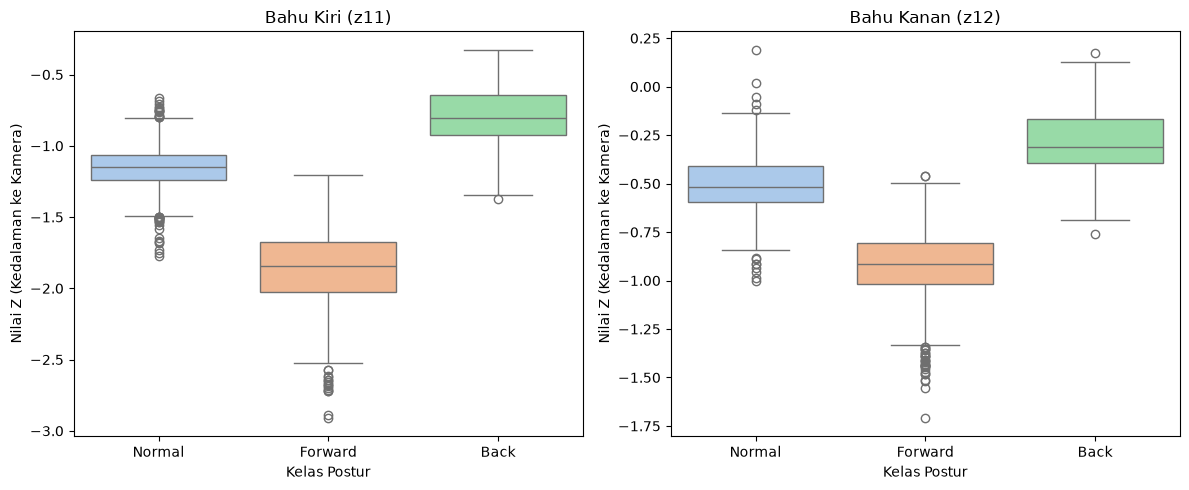

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_main, x='class', y='z11', ax=ax1, palette='pastel')
ax1.set_title('Bahu Kiri (z11)')
ax1.set_ylabel('Nilai Z (Kedalaman ke Kamera)')
ax1.set_xlabel('Kelas Postur')

# 3. Subplot Kanan: Bahu Kanan (z12)
sns.boxplot(data=df_main, x='class', y='z12', ax=ax2, palette='pastel')
ax2.set_title('Bahu Kanan (z12)')
ax2.set_ylabel('Nilai Z (Kedalaman ke Kamera)')
ax2.set_xlabel('Kelas Postur')

# Merapikan jarak antar grafik agar tidak berdempetan
plt.tight_layout()
plt.show()

C:\Users\jason\AppData\Local\Temp\ipykernel_10808\643948600.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='class', y='y2', ax=ax1, palette='pastel')
C:\Users\jason\AppData\Local\Temp\ipykernel_10808\643948600.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_main, x='class', y='y5', ax=ax2, palette='pastel')


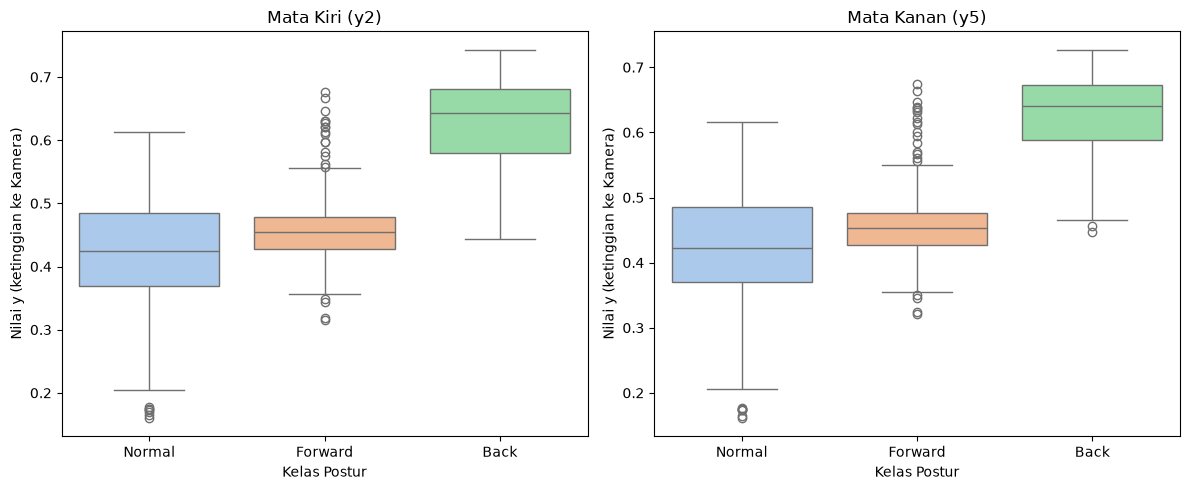

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# subplot kanan: Mata Kiri(y2)
sns.boxplot(data=df_main, x='class', y='y2', ax=ax1, palette='pastel')
ax1.set_title('Mata Kiri (y2)')
ax1.set_ylabel('Nilai y (ketinggian ke Kamera)')
ax1.set_xlabel('Kelas Postur')

# 3. Subplot Kanan: Mata Kanan (y5)
sns.boxplot(data=df_main, x='class', y='y5', ax=ax2, palette='pastel')
ax2.set_title('Mata Kanan (y5)')
ax2.set_ylabel('Nilai y (ketinggian ke Kamera)')
ax2.set_xlabel('Kelas Postur')

# Merapikan jarak antar grafik agar tidak berdempetan
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

print("Memuat dataset original...")
df = pd.read_csv('dataset_postur_v3.csv')

def remove_outliers_per_class(dataframe, columns):
    df_final = pd.DataFrame()
    
    # Pisahkan pembersihan untuk setiap kelas postur
    for posture in dataframe['class'].unique():
        df_class = dataframe[dataframe['class'] == posture].copy()
        
        for col in columns:
            Q1 = df_class[col].quantile(0.25)
            Q3 = df_class[col].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            
            # Filter hanya data yang wajar di kelas tersebut
            df_class = df_class[(df_class[col] >= lower_bound) & (df_class[col] <= upper_bound)]
            
        # Gabungkan kembali data yang sudah bersih
        df_final = pd.concat([df_final, df_class])
        
    return df_final

target_columns = ['y3', 'z3', 'y6', 'z6', 'y12', 'z12', 'y13', 'z13']

df_super_clean = remove_outliers_per_class(df, target_columns)

print(f"Data awal: {len(df)} baris.")
print(f"Data bersih: {len(df_super_clean)} baris.")

df_super_clean.to_csv('dataset_postur_clean.csv', index=False)
print("Save as 'dataset_postur_clean.csv'")

Memuat dataset original...
Data awal: 3871 baris.
Data bersih: 3747 baris.
Save as 'dataset_postur_clean.csv'


In [10]:
# load the cleaned data

df_clean = pd.read_csv('dataset_postur_clean.csv')
df_clean['class'].value_counts()

class
Normal     1392
Back       1238
Forward    1117
Name: count, dtype: int64

C:\Users\jason\AppData\Local\Temp\ipykernel_10808\2033277745.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='class', y='y2', ax=ax1, palette='pastel')
C:\Users\jason\AppData\Local\Temp\ipykernel_10808\2033277745.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='class', y='y5', ax=ax2, palette='pastel')


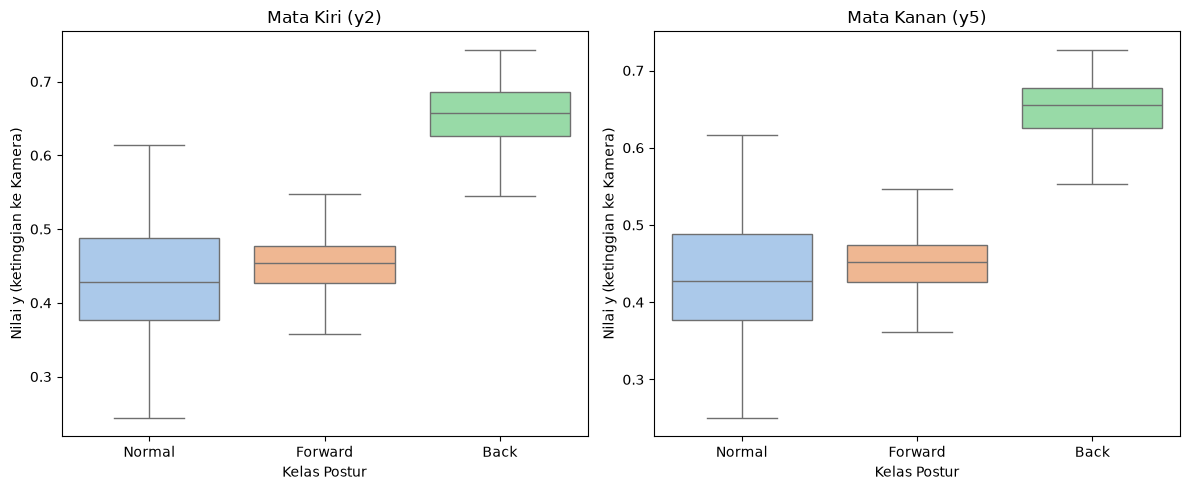

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# subplot kanan: Mata Kiri(y2)
sns.boxplot(data=df_clean, x='class', y='y2', ax=ax1, palette='pastel')
ax1.set_title('Mata Kiri (y2)')
ax1.set_ylabel('Nilai y (ketinggian ke Kamera)')
ax1.set_xlabel('Kelas Postur')

# 3. Subplot Kanan: Mata Kanan (y5)
sns.boxplot(data=df_clean, x='class', y='y5', ax=ax2, palette='pastel')
ax2.set_title('Mata Kanan (y5)')
ax2.set_ylabel('Nilai y (ketinggian ke Kamera)')
ax2.set_xlabel('Kelas Postur')

# Merapikan jarak antar grafik agar tidak berdempetan
plt.tight_layout()
plt.show()

C:\Users\jason\AppData\Local\Temp\ipykernel_10808\3519605707.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='class', y='z11', ax=ax1, palette='pastel')
C:\Users\jason\AppData\Local\Temp\ipykernel_10808\3519605707.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='class', y='z12', ax=ax2, palette='pastel')


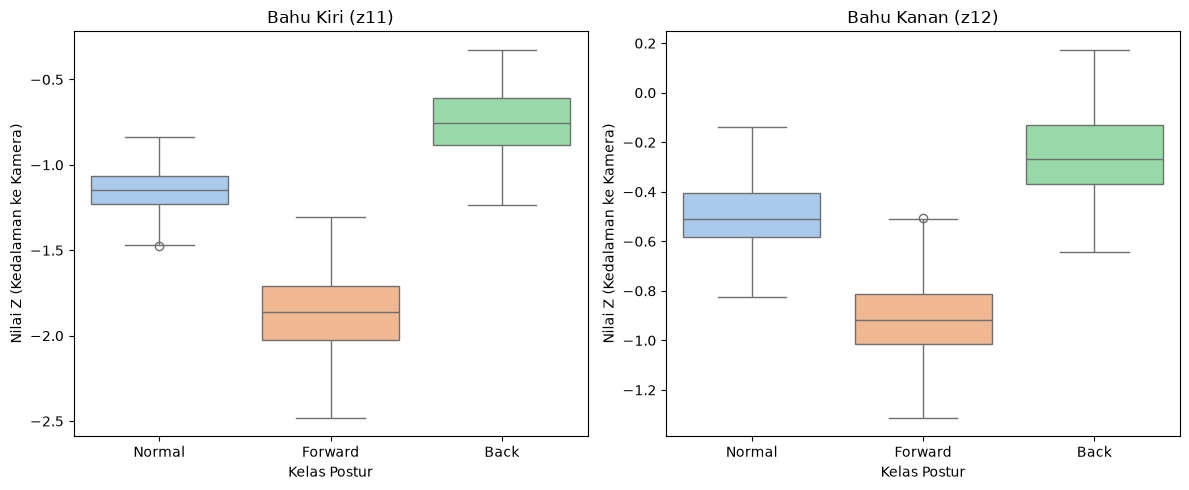

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df_clean, x='class', y='z11', ax=ax1, palette='pastel')
ax1.set_title('Bahu Kiri (z11)')
ax1.set_ylabel('Nilai Z (Kedalaman ke Kamera)')
ax1.set_xlabel('Kelas Postur')

# 3. Subplot Kanan: Bahu Kanan (z12)
sns.boxplot(data=df_clean, x='class', y='z12', ax=ax2, palette='pastel')
ax2.set_title('Bahu Kanan (z12)')
ax2.set_ylabel('Nilai Z (Kedalaman ke Kamera)')
ax2.set_xlabel('Kelas Postur')

# Merapikan jarak antar grafik agar tidak berdempetan
plt.tight_layout()
plt.show()